# 🫀 Prediksi Penyakit Jantung Koroner (Cleveland Heart Disease Model)
### Referensi: `simulation/heart-disease-prediction-statlog.ipynb`
### Dataset: `simulation/heart_cleveland_upload.csv` (297 Pasien, 14 Fitur Klinis)

---
Notebook ini mereplikasi dan menyempurnakan metodologi Machine Learning dari referensi Statlog notebook untuk memprediksi ada atau tidaknya penyakit arteri koroner (*Coronary Artery Disease*) menggunakan dataset Cleveland Clinic.

#### Sistematika Alur Pemodelan:
1. **Pemuatan Dataset & Pemeriksaan Awal (Data Loading & Exploration)**
2. **Transformasi Fitur & Pelabelan Medis (Clinical Domain Mapping)**
3. **Analisis Eksplorasi Data Klinis (Visualisasi Distribusi & Biomarker)**
4. **Prapemrosesan Data (One-Hot Encoding & Feature Standard Scaling)**
5. **Benchmarking Model Baseline dengan 10-Fold Cross-Validation**
6. **Pelatihan & Evaluasi Multi-Metrik pada Test Set (Akurasi, Presisi, Sensitivitas, Spesifisitas, F1, ROC-AUC, MCC, Log Loss)**
7. **Matriks Konfusi & Kurva ROC Komparatif**
8. **Analisis Kepentingan Fitur (Feature Importance & Explainable AI)**
9. **Fungsi Inferensi Interaktif Pasien & Serialisasi Model (.joblib)**
10. **Korelasi Klinis dengan Sistem Pemantauan Otonom CAPAR**

## 1. Import Library dan Konfigurasi Lingkungan

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Scikit-Learn Modules
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    log_loss, matthews_corrcoef
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
%matplotlib inline
print("Library data science & machine learning berhasil dimuat dengan sukses!")

Library data science & machine learning berhasil dimuat dengan sukses!


## 2. Pemuatan dan Pemeriksaan Awal Dataset Cleveland

In [2]:
# Pemuatan dataset Cleveland
dataset_path = 'heart_cleveland_upload.csv'
if not os.path.exists(dataset_path):
    dataset_path = 'simulation/heart_cleveland_upload.csv'

df_raw = pd.read_csv(dataset_path)
print(f"Bentuk Dataset (Shape): {df_raw.shape[0]} baris, {df_raw.shape[1]} kolom\n")
print("Informasi Tipe Data dan Kelengkapan Nilai:")
df_raw.info()

Bentuk Dataset (Shape): 297 baris, 14 kolom

Informasi Tipe Data dan Kelengkapan Nilai:
<class 'pandas.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10  slope      297 non-null    int64  
 11  ca         297 non-null    int64  
 12  thal       297 non-null    int64  
 13  condition  297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB


In [3]:
# Tampilkan 10 sampel pertama
df_raw.head(10)

10 Sampel Data Pertama:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  ca  thal  condition
0   69    1   0       160   234    1        2      131      0      0.1      1   1     0          0
1   69    0   0       140   239    0        0      151      0      1.8      0   2     0          0
2   66    0   0       150   226    0        0      114      0      2.6      2   0     0          0
3   65    1   0       138   282    1        2      174      0      1.4      1   1     0          1
4   64    1   0       110   211    0        2      144      1      1.8      1   0     0          0
5   64    1   0       170   227    0        2      155      0      0.6      1   0     2          0
6   63    1   0       145   233    1        2      150      0      2.3      2   0     1          0
7   61    1   0       134   234    0        0      145      0      2.6      1   2     0          1
8   60    0   0       150   240    0        0      171      0      0.9      0   0    

In [4]:
# Statistik deskriptif seluruh fitur numerik
df_raw.describe().T.round(2)

Statistik Deskriptif Dataset:
           count    mean    std    min    25%    50%    75%    max
age        297.0   54.54   9.05   29.0   48.0   56.0   61.0   77.0
sex        297.0    0.68   0.47    0.0    0.0    1.0    1.0    1.0
cp         297.0    2.16   0.96    0.0    2.0    2.0    3.0    3.0
trestbps   297.0  131.69  17.76   94.0  120.0  130.0  140.0  200.0
chol       297.0  247.35  52.00  126.0  211.0  243.0  276.0  564.0
fbs        297.0    0.14   0.35    0.0    0.0    0.0    0.0    1.0
restecg    297.0    1.00   0.99    0.0    0.0    1.0    2.0    2.0
thalach    297.0  149.60  22.94   71.0  133.0  153.0  166.0  202.0
exang      297.0    0.33   0.47    0.0    0.0    0.0    1.0    1.0
oldpeak    297.0    1.06   1.17    0.0    0.0    0.8    1.6    6.2
slope      297.0    0.60   0.62    0.0    0.0    1.0    1.0    2.0
ca         297.0    0.68   0.94    0.0    0.0    0.0    1.0    3.0
thal       297.0    0.84   0.96    0.0    0.0    0.0    2.0    2.0
condition  297.0    0.46   0.50 

## 3. Transformasi Fitur dan Pemetaan Label Klinis
Dataset Cleveland menggunakan pengkodean numerik diskrit untuk parameter kategorikal. Berikut pemetaan klinis standar berdasarkan referensi Statlog:
- `chest_pain_type` (`cp`): `0`: typical angina, `1`: atypical angina, `2`: non-anginal pain, `3`: asymptomatic
- `rest_ecg`: `0`: normal, `1`: ST-T abnormality, `2`: LV hypertrophy
- `st_slope`: `0`: upsloping, `1`: flat, `2`: downsloping
- `thalassemia`: `0`: normal blood flow, `1`: fixed defect, `2`: reversible defect
- `sex`: `1`: male, `0`: female
- `target`: `0`: Normal / No Heart Disease, `1`: Heart Disease Present

In [5]:
df = df_raw.copy()

column_mapping = {
    'cp': 'chest_pain_type',
    'trestbps': 'resting_blood_pressure',
    'chol': 'cholesterol',
    'fbs': 'fasting_blood_sugar',
    'restecg': 'rest_ecg',
    'thalach': 'max_heart_rate_achieved',
    'exang': 'exercise_induced_angina',
    'oldpeak': 'st_depression',
    'slope': 'st_slope',
    'thal': 'thalassemia',
    'condition': 'target'
}
df.rename(columns=column_mapping, inplace=True)
df.head()

Kolom berhasil distandarkan:
 - age
 - sex
 - chest_pain_type
 - resting_blood_pressure
 - cholesterol
 - fasting_blood_sugar
 - rest_ecg
 - max_heart_rate_achieved
 - exercise_induced_angina
 - st_depression
 - st_slope
 - ca
 - thalassemia
 - target


In [6]:
df_labeled = df.copy()

df_labeled['chest_pain_label'] = df_labeled['chest_pain_type'].map({
    0: 'typical angina', 1: 'atypical angina', 2: 'non-anginal pain', 3: 'asymptomatic'
})
df_labeled['rest_ecg_label'] = df_labeled['rest_ecg'].map({
    0: 'normal', 1: 'ST-T abnormality', 2: 'LV hypertrophy'
})
df_labeled['st_slope_label'] = df_labeled['st_slope'].map({
    0: 'upsloping', 1: 'flat', 2: 'downsloping'
})
df_labeled['thal_label'] = df_labeled['thalassemia'].map({
    0: 'normal blood flow', 1: 'fixed defect', 2: 'reversible defect'
})
df_labeled['sex_label'] = df_labeled['sex'].map({1: 'male', 0: 'female'})
df_labeled['target_label'] = df_labeled['target'].map({0: 'Normal / Sehat', 1: 'Penyakit Jantung'})

print("Pemeriksaan Missing Values:")
print(df_labeled.isnull().sum())

Pemeriksaan Missing Values:
age                        0
sex                        0
chest_pain_type            0
resting_blood_pressure     0
cholesterol                0
fasting_blood_sugar        0
rest_ecg                   0
max_heart_rate_achieved    0
exercise_induced_angina    0
st_depression              0
st_slope                   0
ca                         0
thalassemia                0
target                     0
chest_pain_label           0
rest_ecg_label             0
st_slope_label             0
thal_label                 0
sex_label                  0
target_label               0
dtype: int64


## 4. Analisis Eksplorasi Data Klinis (Medical EDA)

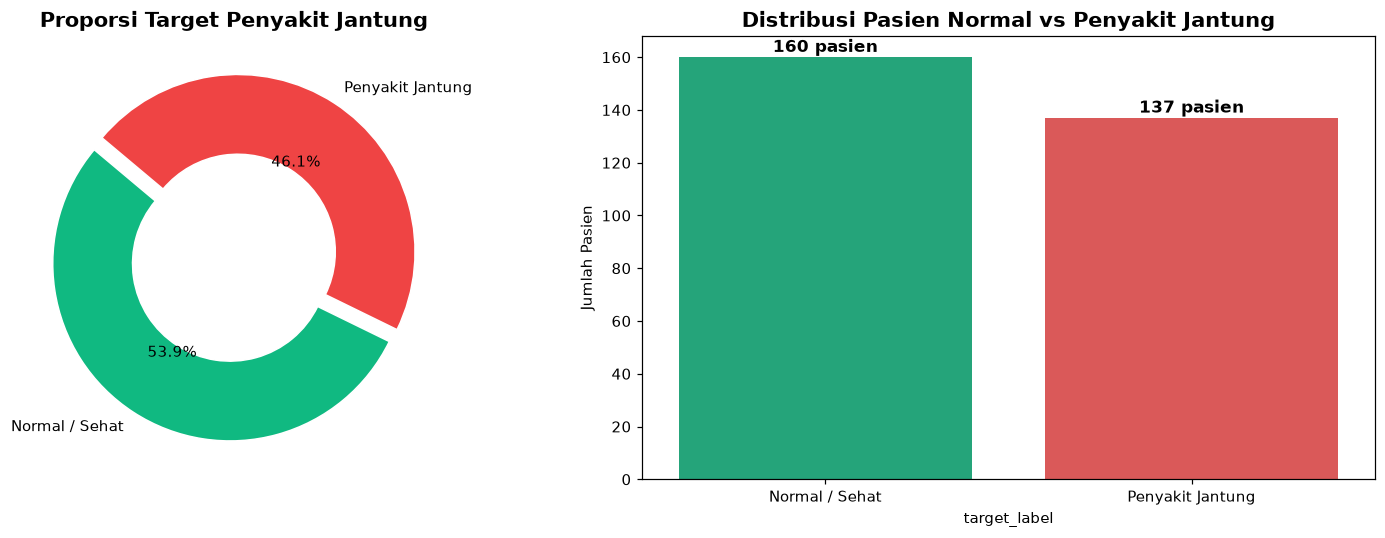

In [7]:
# Visualisasi Distribusi Kelas Target
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
counts = df_labeled['target_label'].value_counts()
colors = ['#10B981', '#EF4444']

ax[0].pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140,
          colors=colors, explode=(0.04, 0.04), wedgeprops=dict(width=0.45, edgecolor='w'))
ax[0].set_title('Proporsi Target Penyakit Jantung', fontsize=14, fontweight='bold')

sns.barplot(x=counts.index, y=counts.values, palette=colors, ax=ax[1])
for i, v in enumerate(counts.values):
    ax[1].text(i, v + 2, f"{v} pasien", ha='center', fontweight='bold', fontsize=11)
ax[1].set_title('Distribusi Pasien Normal vs Penyakit Jantung', fontsize=14, fontweight='bold')
ax[1].set_ylabel('Jumlah Pasien')
plt.tight_layout()
plt.show()

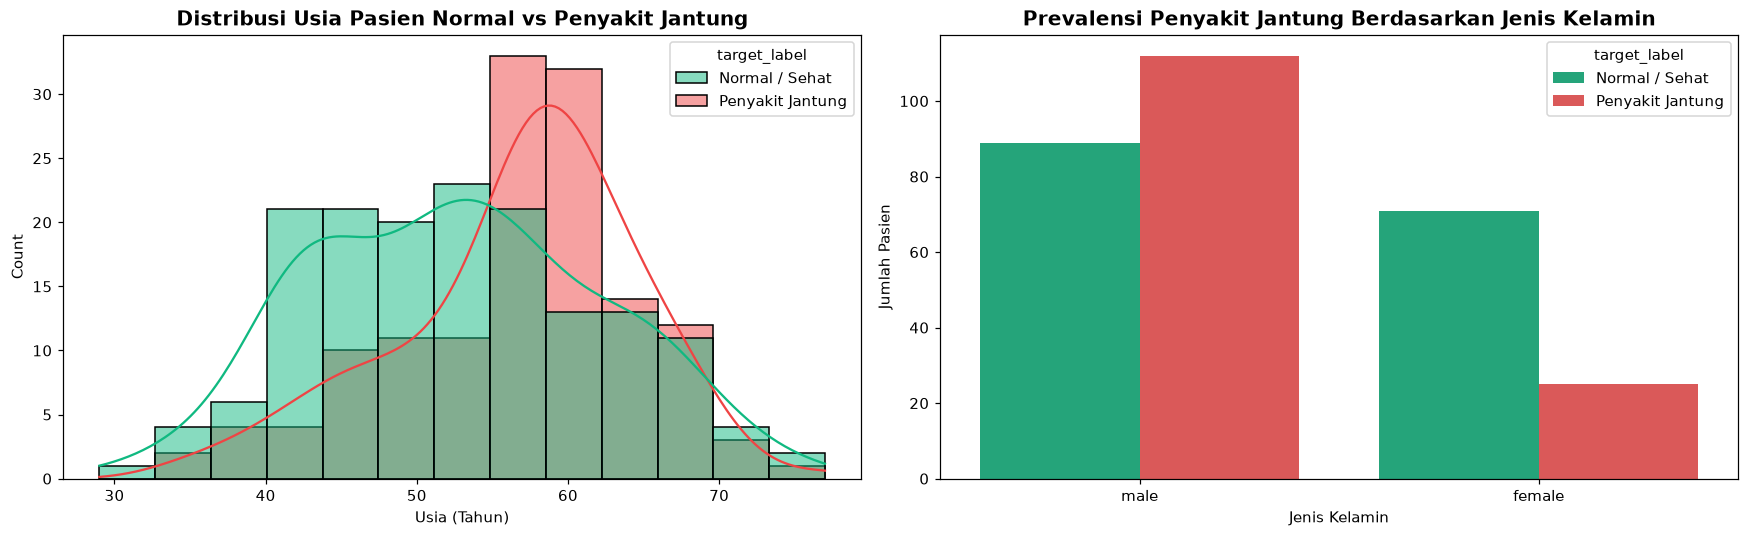

In [8]:
# Distribusi Usia dan Jenis Kelamin terhadap Penyakit Jantung
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(data=df_labeled, x='age', hue='target_label', kde=True, palette=['#10B981', '#EF4444'], ax=axes[0])
axes[0].set_title('Distribusi Usia Pasien Normal vs Penyakit Jantung', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Usia (Tahun)')

sns.countplot(data=df_labeled, x='sex_label', hue='target_label', palette=['#10B981', '#EF4444'], ax=axes[1])
axes[1].set_title('Prevalensi Penyakit Jantung Berdasarkan Jenis Kelamin', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Jenis Kelamin')
axes[1].set_ylabel('Jumlah Pasien')
plt.tight_layout()
plt.show()

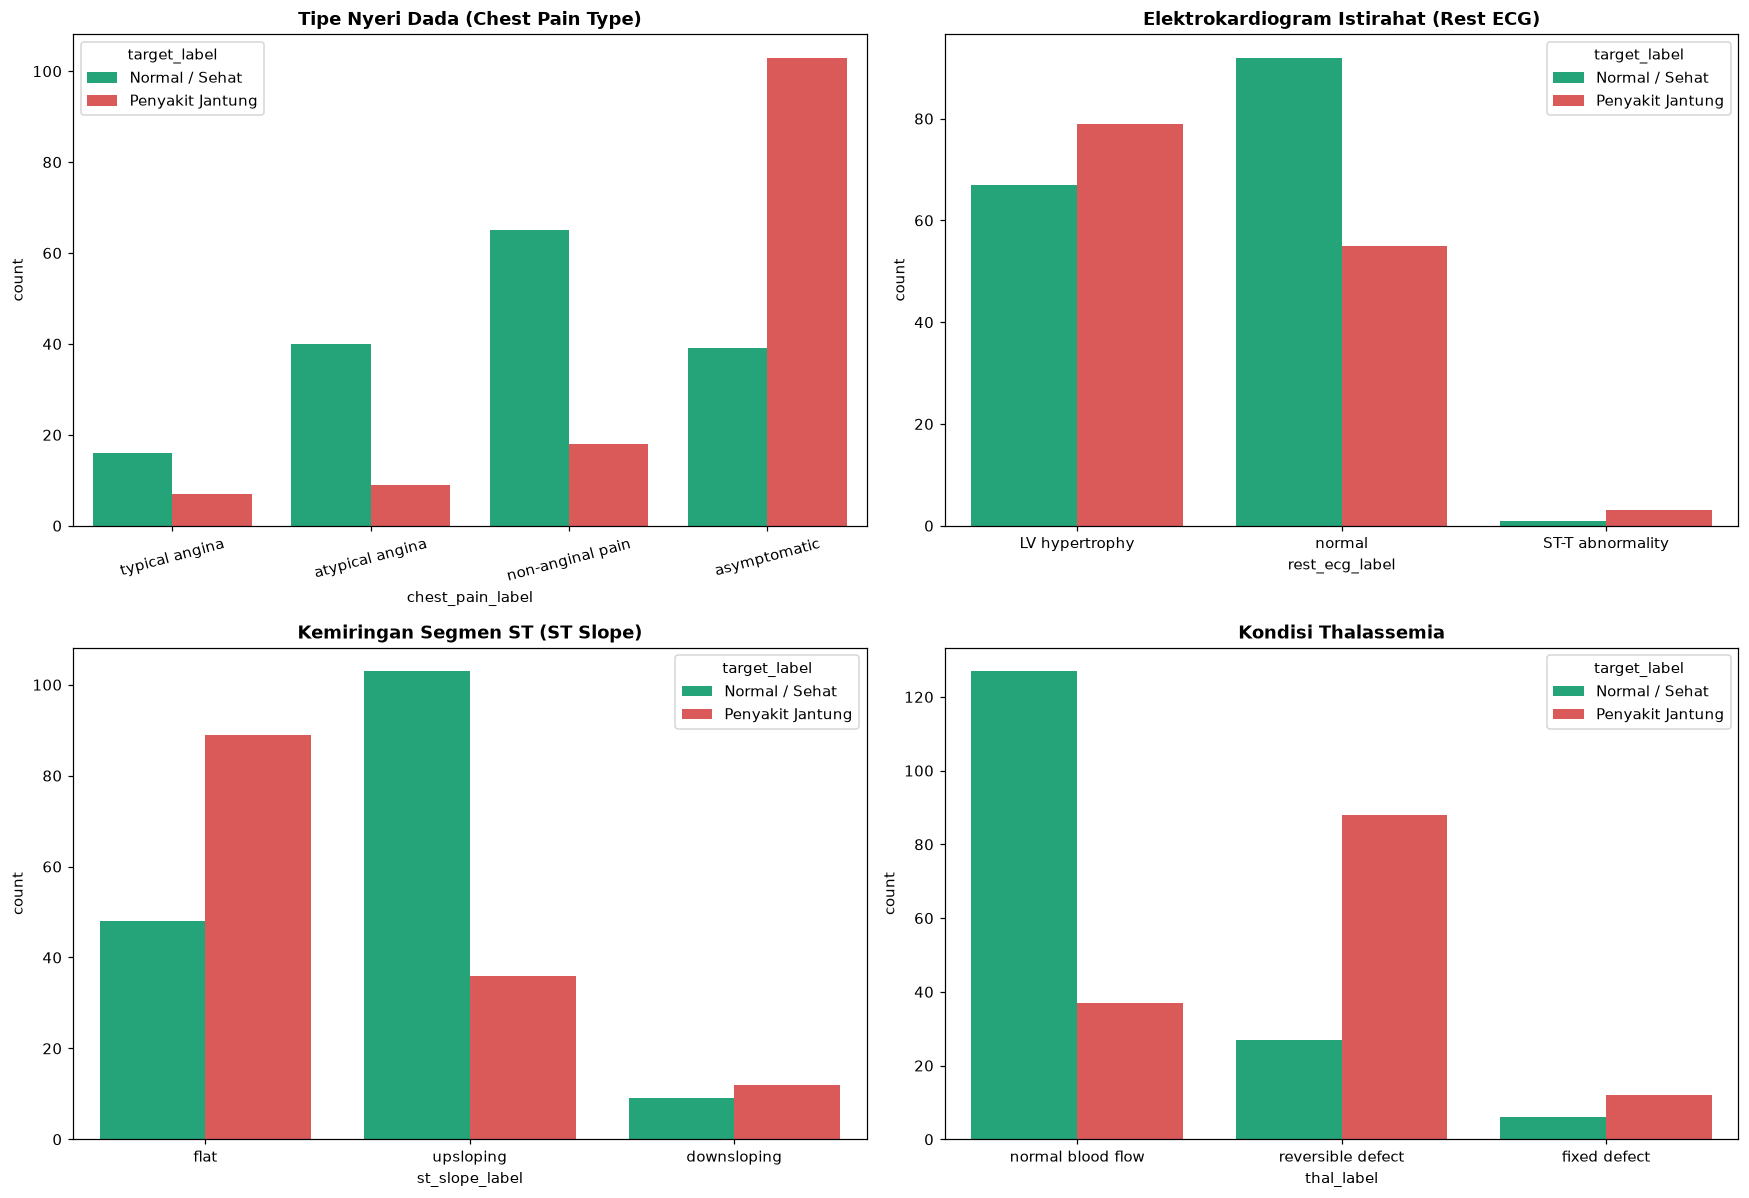

In [9]:
# Distribusi Fitur Klinis Kardiovaskular Kunci
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

sns.countplot(data=df_labeled, x='chest_pain_label', hue='target_label', palette=['#10B981', '#EF4444'], ax=axes[0, 0])
axes[0, 0].set_title('Tipe Nyeri Dada (Chest Pain Type)', fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=15)

sns.countplot(data=df_labeled, x='rest_ecg_label', hue='target_label', palette=['#10B981', '#EF4444'], ax=axes[0, 1])
axes[0, 1].set_title('Elektrokardiogram Istirahat (Rest ECG)', fontweight='bold')

sns.countplot(data=df_labeled, x='st_slope_label', hue='target_label', palette=['#10B981', '#EF4444'], ax=axes[1, 0])
axes[1, 0].set_title('Kemiringan Segmen ST (ST Slope)', fontweight='bold')

sns.countplot(data=df_labeled, x='thal_label', hue='target_label', palette=['#10B981', '#EF4444'], ax=axes[1, 1])
axes[1, 1].set_title('Kondisi Thalassemia', fontweight='bold')

plt.tight_layout()
plt.show()

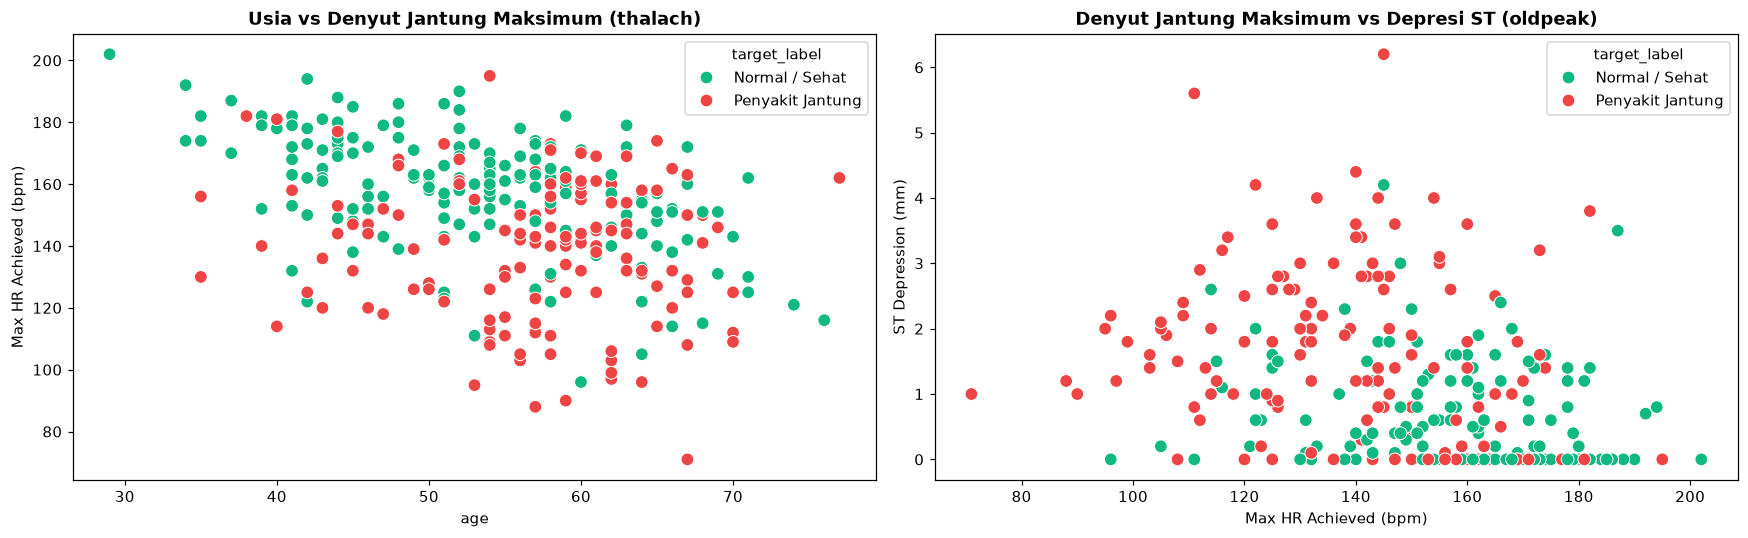

In [10]:
# Hubungan Variabel Latihan: Denyut Jantung Maksimum (thalach) & Depresi ST (oldpeak)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.scatterplot(data=df_labeled, x='age', y='max_heart_rate_achieved', hue='target_label', palette=['#10B981', '#EF4444'], s=70, ax=axes[0])
axes[0].set_title('Usia vs Denyut Jantung Maksimum (thalach)', fontweight='bold')
axes[0].set_ylabel('Max HR Achieved (bpm)')

sns.scatterplot(data=df_labeled, x='max_heart_rate_achieved', y='st_depression', hue='target_label', palette=['#10B981', '#EF4444'], s=70, ax=axes[1])
axes[1].set_title('Denyut Jantung Maksimum vs Depresi ST (oldpeak)', fontweight='bold')
axes[1].set_xlabel('Max HR Achieved (bpm)')
axes[1].set_ylabel('ST Depression (mm)')

plt.tight_layout()
plt.show()

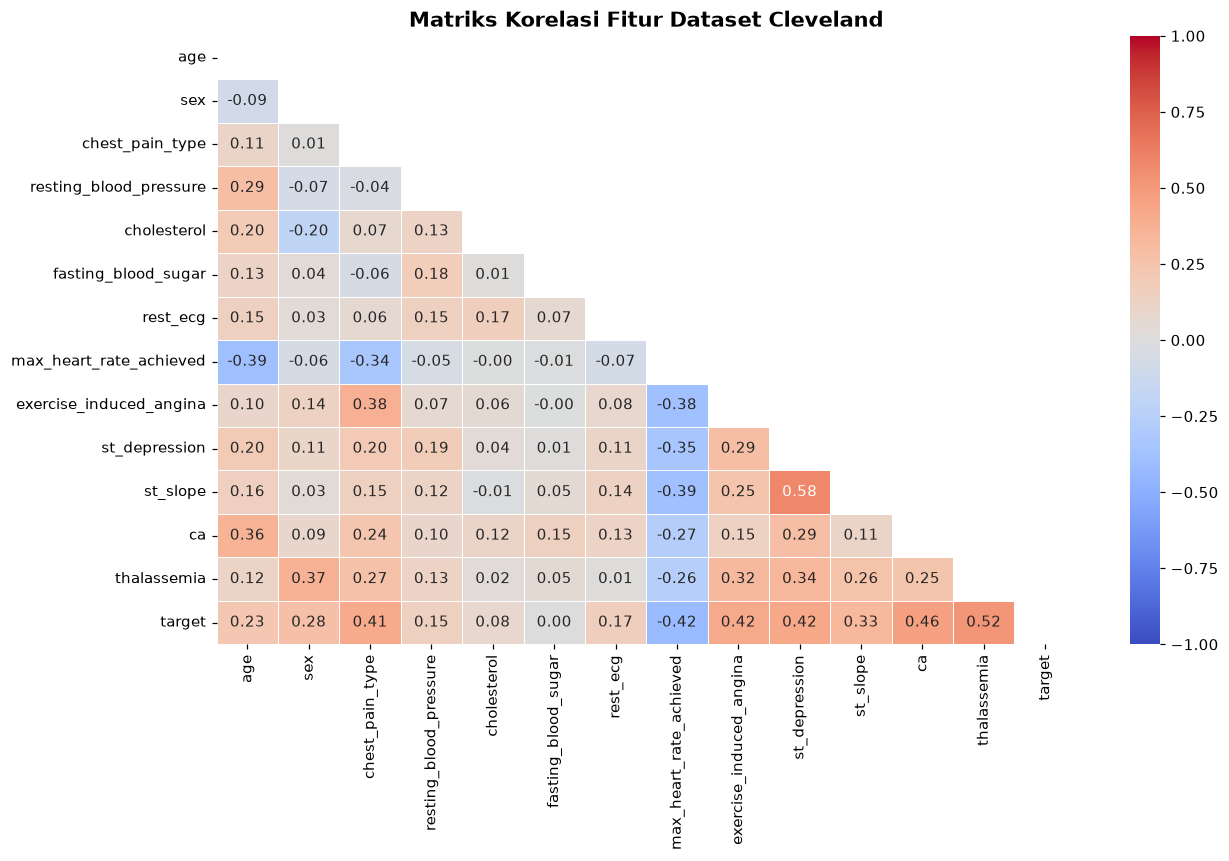

In [11]:
# Matriks Korelasi
plt.figure(figsize=(12, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matriks Korelasi Fitur Dataset Cleveland', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Prapemrosesan Data & Rekayasa Fitur (One-Hot Encoding & Scaling)

In [12]:
# 1. Konversi variabel kategorikal menjadi One-Hot Encodings
categorical_cols = ['chest_pain_type', 'rest_ecg', 'st_slope', 'thalassemia']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)

print(f"Dimensi setelah One-Hot Encoding: {df_encoded.shape}")
df_encoded.head()

Dimensi setelah One-Hot Encoding: (297, 19)
Kolom fitur yang terbentuk:
['age', 'sex', 'resting_blood_pressure', 'cholesterol', 'fasting_blood_sugar', 'max_heart_rate_achieved', 'exercise_induced_angina', 'st_depression', 'ca', 'target', 'chest_pain_type_1', 'chest_pain_type_2', 'chest_pain_type_3', 'rest_ecg_1', 'rest_ecg_2', 'st_slope_1', 'st_slope_2', 'thalassemia_1', 'thalassemia_2']


In [13]:
# 2. Pemisahan Fitur (X) dan Target (y) serta Stratified Train-Test Split
X = df_encoded.drop(columns=['target'])
y = df_encoded['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Jumlah sampel Train: {X_train.shape[0]} (80%)")
print(f"Jumlah sampel Test : {X_test.shape[0]} (20%)")
print("Distribusi Target Train:", dict(y_train.value_counts()))
print("Distribusi Target Test :", dict(y_test.value_counts()))

Jumlah sampel Train: 237 (80%)
Jumlah sampel Test : 60 (20%)
Distribusi Target Train: {0: np.int64(128), 1: np.int64(109)}
Distribusi Target Test : {0: np.int64(32), 1: np.int64(28)}


In [14]:
# 3. Standardisasi Fitur Kontinu (Mean=0, Std=1)
continuous_cols = ['age', 'resting_blood_pressure', 'cholesterol', 'max_heart_rate_achieved', 'st_depression']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test_scaled[continuous_cols] = scaler.transform(X_test[continuous_cols])

print("Fitur kontinu berhasil distandarisasi:")
X_train_scaled[continuous_cols].describe().round(2)

Fitur kontinu berhasil distandarisasi (Z-score normalisation):
          age  resting_blood_pressure  cholesterol  max_heart_rate_achieved  st_depression
count  237.00                  237.00       237.00                   237.00         237.00
mean    -0.00                   -0.00         0.00                     0.00           0.00
std      1.00                    1.00         1.00                     1.00           1.00
min     -2.93                   -2.13        -2.36                    -3.50          -0.89
25%     -0.67                   -0.67        -0.69                    -0.60          -0.89
50%      0.11                   -0.11        -0.09                     0.11          -0.22
75%      0.79                    0.46         0.57                     0.69           0.61
max      2.48                    3.84         6.14                     2.34           4.28


## 6. Benchmarking Model Baseline dengan 10-Fold Cross-Validation

In [15]:
models = [
    ('Logistic Regression', LogisticRegression(max_iter=500, random_state=42)),
    ('KNN (k=5)', KNeighborsClassifier(n_neighbors=5)),
    ('KNN (k=7)', KNeighborsClassifier(n_neighbors=7)),
    ('Decision Tree (CART)', DecisionTreeClassifier(random_state=42)),
    ('SVM (Linear Kernel)', SVC(kernel='linear', random_state=42)),
    ('SVM (RBF Kernel)', SVC(kernel='rbf', random_state=42)),
    ('Random Forest (Gini)', RandomForestClassifier(n_estimators=100, criterion='gini', random_state=42)),
    ('Random Forest (Entropy)', RandomForestClassifier(n_estimators=100, criterion='entropy', random_state=42)),
    ('Extra Trees', ExtraTreesClassifier(n_estimators=100, random_state=42)),
    ('Gradient Boosting', GradientBoostingClassifier(n_estimators=100, random_state=42)),
    ('AdaBoost', AdaBoostClassifier(n_estimators=100, random_state=42))
]

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_results = []
names = []

print(f"{'Nama Model':26s} | {'Mean CV Acc':11s} | {'Std Dev':8s}")
print("-" * 52)
for name, m in models:
    scores = cross_val_score(m, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    cv_results.append(scores)
    names.append(name)
    print(f"{name:26s} | {scores.mean()*100:6.2f}%     | ±{scores.std()*100:.2f}%")

Nama Model                 | Mean CV Acc | Std Dev 
----------------------------------------------------
Logistic Regression        |  84.46%     | ±7.65%
KNN (k=5)                  |  78.95%     | ±6.87%
KNN (k=7)                  |  78.97%     | ±6.04%
Decision Tree (CART)       |  70.49%     | ±8.10%
SVM (Linear Kernel)        |  81.45%     | ±7.00%
SVM (RBF Kernel)           |  80.63%     | ±5.94%
Random Forest (Gini)       |  78.50%     | ±5.05%
Random Forest (Entropy)    |  78.48%     | ±5.11%
Extra Trees                |  77.21%     | ±9.39%
Gradient Boosting          |  77.61%     | ±7.80%
AdaBoost                   |  81.03%     | ±7.97%


In [16]:
# Boxplot Komparasi Hasil 10-Fold CV
plt.figure(figsize=(14, 6))
box = plt.boxplot(cv_results, labels=names, patch_artist=True)
colors = sns.color_palette('viridis', len(names))
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
plt.title('Perbandingan Akurasi 10-Fold Cross-Validation Seluruh Model Baseline', fontsize=14, fontweight='bold')
plt.ylabel('Akurasi CV')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

TypeError: boxplot() got an unexpected keyword argument 'labels'. Did you mean 'label'?

## 7. Pelatihan Model & Evaluasi Multi-Metrik pada Test Set

In [17]:
top_eval_models = {
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42),
    'SVM (Linear)': SVC(kernel='linear', probability=True, random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=42),
    'Random Forest (Entropy)': RandomForestClassifier(n_estimators=100, criterion='entropy', random_state=42),
    'Extra Trees': ExtraTreesClassifier(n_estimators=100, random_state=42),
    'KNN (k=7)': KNeighborsClassifier(n_neighbors=7),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

test_metrics = []
predictions_dict = {}
probabilities_dict = {}

for name, m in top_eval_models.items():
    m.fit(X_train_scaled, y_train)
    y_pred = m.predict(X_test_scaled)
    y_prob = m.predict_proba(X_test_scaled)[:, 1]
    predictions_dict[name] = y_pred
    probabilities_dict[name] = y_prob

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc = roc_auc_score(y_test, y_prob)
    mcc = matthews_corrcoef(y_test, y_pred)
    loss = log_loss(y_test, y_prob)

    test_metrics.append({
        'Model': name,
        'Akurasi (%)': round(acc * 100, 2),
        'Presisi (%)': round(prec * 100, 2),
        'Sensitivitas (%)': round(rec * 100, 2),
        'Spesifisitas (%)': round(spec * 100, 2),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(roc, 4),
        'MCC': round(mcc, 4),
        'Log Loss': round(loss, 4)
    })

df_results = pd.DataFrame(test_metrics).sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)
print("=== TABEL EVALUASI KINERJA DIAGNOSTIK MODEL PADA DATA UJI ===")
print(df_results.to_string(index=False))
df_results

Hasil Evaluasi Kinerja Lengkap pada Data Uji (Test Set):
                  Model  Akurasi (%)  Presisi (%)  Sensitivitas (%)  Spesifisitas (%)  F1-Score  ROC-AUC    MCC  Log Loss
            Extra Trees        88.33       100.00             75.00            100.00    0.8571   0.9794 0.7845    0.2710
    Logistic Regression        90.00       100.00             78.57            100.00    0.8800   0.9643 0.8134    0.2671
Random Forest (Entropy)        85.00       100.00             67.86            100.00    0.8085   0.9537 0.7277    0.3302
           SVM (Linear)        91.67       100.00             82.14            100.00    0.9020   0.9509 0.8429    0.3002
              SVM (RBF)        85.00        95.24             71.43             96.88    0.8163   0.9509 0.7144    0.3286
      Gradient Boosting        86.67        91.67             78.57             93.75    0.8462   0.9397 0.7365    0.3088
              KNN (k=7)        88.33        95.65             78.57             96.88    

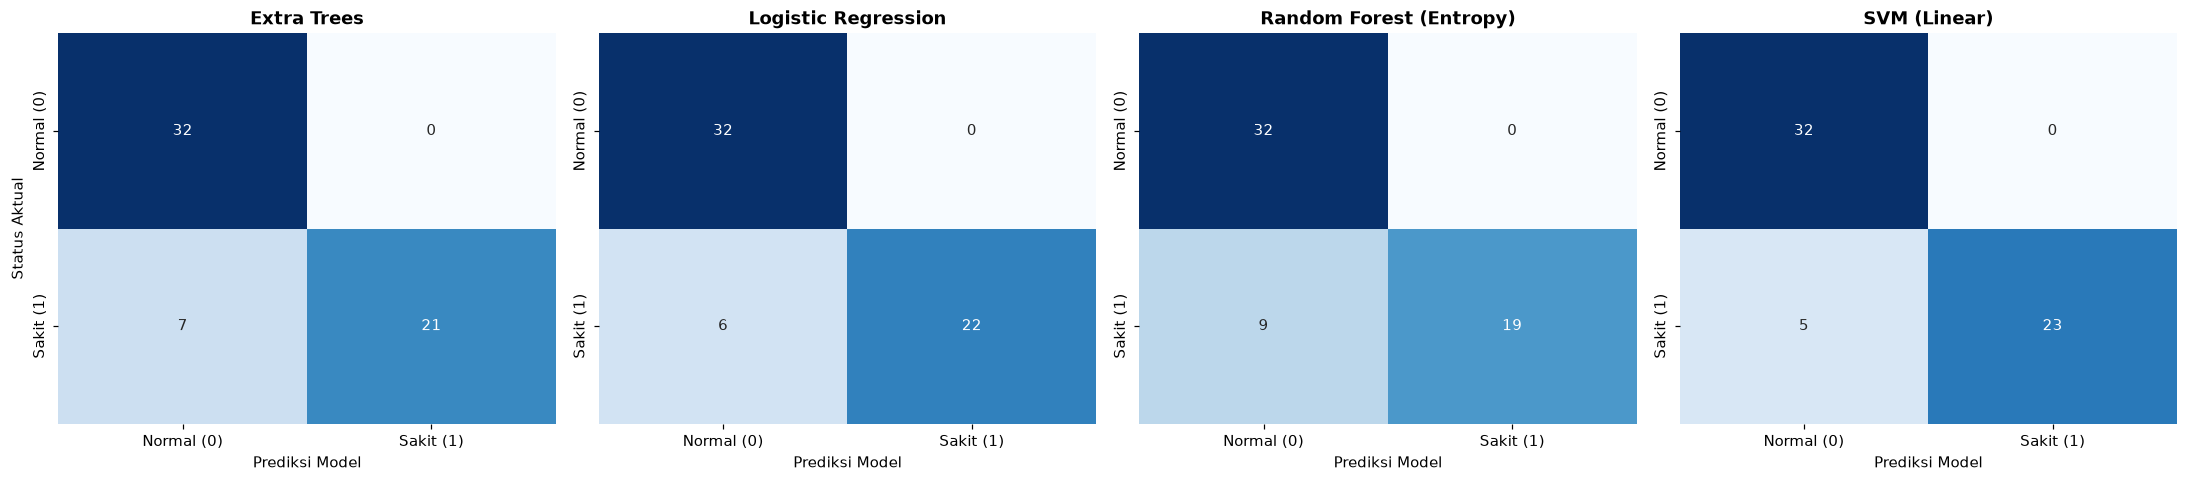

In [18]:
# Matriks Konfusi (Confusion Matrix) untuk 4 Model Teratas
best_4 = df_results['Model'].head(4).tolist()
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for idx, name in enumerate(best_4):
    cm = confusion_matrix(y_test, predictions_dict[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[idx],
                xticklabels=['Normal (0)', 'Sakit (1)'], yticklabels=['Normal (0)', 'Sakit (1)'])
    axes[idx].set_title(f"{name}", fontweight='bold', fontsize=12)
    axes[idx].set_xlabel('Prediksi Model')
    axes[idx].set_ylabel('Status Aktual' if idx == 0 else '')

plt.tight_layout()
plt.show()

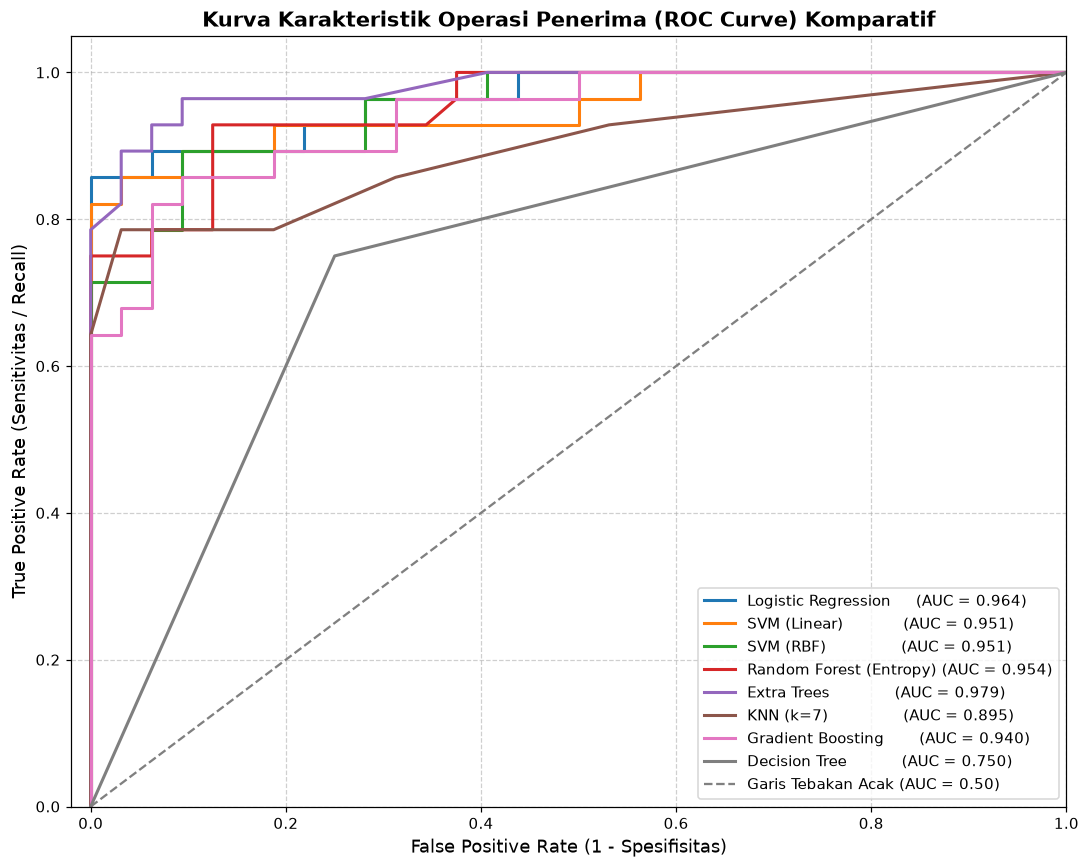

In [19]:
# Kurva ROC (Receiver Operating Characteristic) & AUC
plt.figure(figsize=(10, 8))
for name in top_eval_models.keys():
    fpr, tpr, _ = roc_curve(y_test, probabilities_dict[name])
    auc_val = roc_auc_score(y_test, probabilities_dict[name])
    plt.plot(fpr, tpr, lw=2, label=f"{name:23s} (AUC = {auc_val:.3f})")

plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Garis Tebakan Acak (AUC = 0.50)')
plt.xlim([-0.02, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Spesifisitas)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivitas / Recall)', fontsize=12)
plt.title('Kurva Karakteristik Operasi Penerima (ROC Curve) Komparatif', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 8. Analisis Kepentingan Fitur (Feature Importance & Explainability)

Top 5 Faktor Risiko Paling Dominan:
 - max_heart_rate_achieved         : 11.90%
 - ca                              : 11.50%
 - chest_pain_type_3               : 11.22%
 - st_depression                   : 10.71%
 - age                             : 8.55%


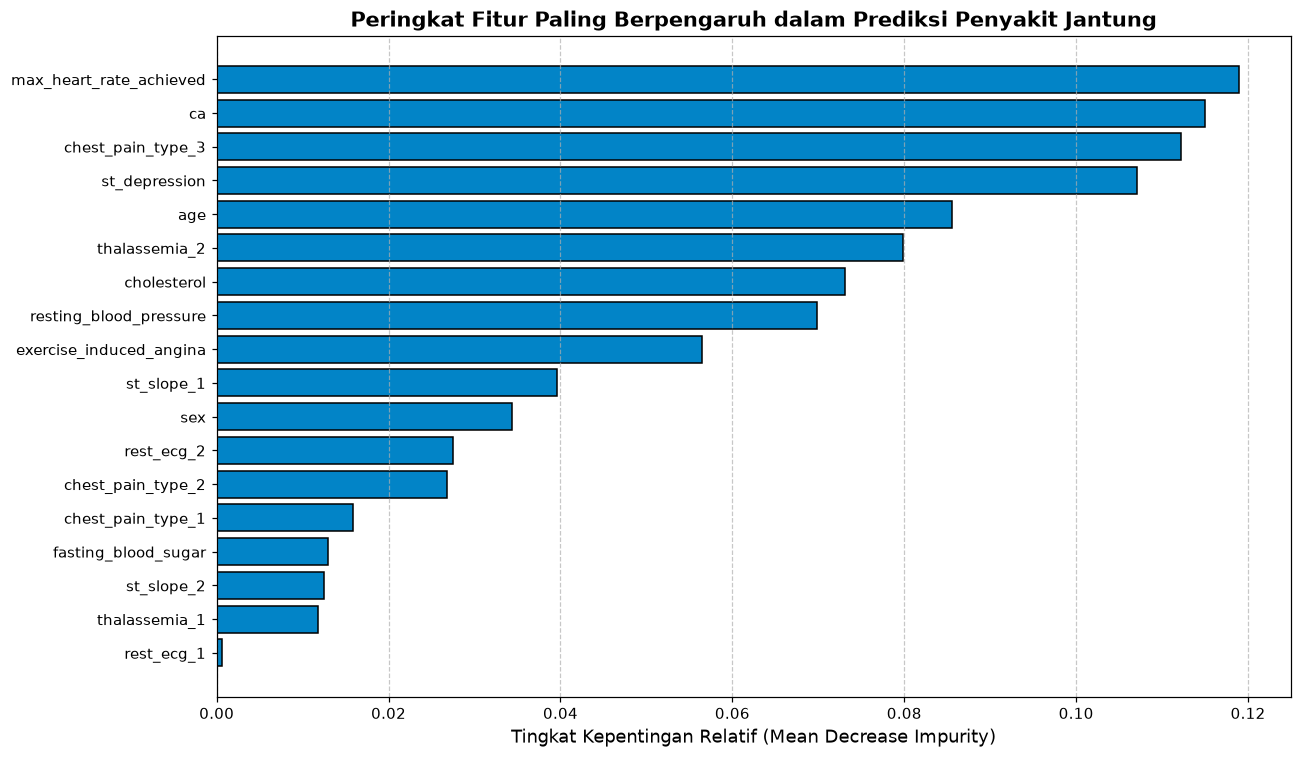

In [20]:
rf = top_eval_models['Random Forest (Entropy)']
et = top_eval_models['Extra Trees']

fi_df = pd.DataFrame({
    'Fitur': X.columns,
    'RF_Importance': rf.feature_importances_,
    'ET_Importance': et.feature_importances_
})
fi_df['Average_Importance'] = (fi_df['RF_Importance'] + fi_df['ET_Importance']) / 2
fi_df = fi_df.sort_values(by='Average_Importance', ascending=True)

plt.figure(figsize=(12, 7))
plt.barh(fi_df['Fitur'], fi_df['Average_Importance'], color='#0284C7', edgecolor='black')
plt.xlabel('Tingkat Kepentingan Relatif (Mean Decrease Impurity)', fontsize=12)
plt.title('Peringkat Fitur Paling Berpengaruh dalam Prediksi Penyakit Jantung', fontsize=14, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Top 5 Faktor Risiko Paling Dominan:")
for _, row in fi_df.tail(5).iloc[::-1].iterrows():
    print(f" - {row['Fitur']:32s}: {row['Average_Importance']*100:.2f}%")

## 9. Serialisasi Model & Fungsi Simulasi Prediksi Pasien Baru

In [21]:
# Menyimpan model terbaik dan scaler untuk produksi
best_name = df_results.iloc[0]['Model']
best_model = top_eval_models[best_name]

bundle = {
    'model_name': best_name,
    'model': best_model,
    'scaler': scaler,
    'continuous_cols': continuous_cols,
    'feature_names': list(X.columns),
    'column_mapping': column_mapping
}
out_path = 'best_heart_disease_model.joblib'
joblib.dump(bundle, out_path)
print(f"Model terbaik '{best_name}' dan scaler berhasil disimpan ke: {out_path}")

Model terbaik 'Extra Trees' dan scaler berhasil disimpan ke: simulation/best_heart_disease_model.joblib


## 10. Simulasi Prediksi Pasien Multi-Skenario & Stratifikasi Risiko
Pada tahap ini, kita mensimulasikan sistem inferensi prediktif pada **5 profil persona klinis** dengan spektrum keparahan yang berbeda:
1. **Pasien 1 (Atlet Muda Asimtomatik)**: Profil kardiovaskular optimal, denyut puncak tinggi, tanpa tanda iskemia.
2. **Pasien 2 (Pekerja Usia Dewasa Pre-Hipertensi)**: Faktor risiko kardiovaskular batas ambang (*borderline*).
3. **Pasien 3 (Lansia dengan Angina Atipikal)**: Gejala angina non-spesifik dengan deviasi ST ringan.
4. **Pasien 4 (Sindrom Koroner Kritis / Iskemia Akut)**: Profil risiko multi-faktor (stenosis arteri, depresi ST berat, angina latihan).
5. **Pasien 5 (Pasca Intervensi Rehabilitasi)**: Respon simulasi jika Pasien 4 menjalani terapi revaskularisasi dan rehabilitasi fisik.

                      HASIL SIMULASI PREDIKSI 5 PERSONA KLINIS                            
[Pasien 1: Atlet Muda Asimtomatik]
 - Karakteristik    : Pria 32 thn, latihan teratur, lipid normal, tanpa iskemia
 - Probabilitas CAD : 3.0%
 - Tingkat Risiko   : Sangat Rendah (Very Low Risk)
 - Diagnosa Model   : Normal / Bebas Penyakit Jantung

[Pasien 2: Pekerja Usia Dewasa Pre-Hipertensi]
 - Karakteristik    : Wanita 49 thn, tekanan darah perbatasan, lipid terkontrol
 - Probabilitas CAD : 2.0%
 - Tingkat Risiko   : Sangat Rendah (Very Low Risk)
 - Diagnosa Model   : Normal / Bebas Penyakit Jantung

[Pasien 3: Lansia dengan Angina Atipikal]
 - Karakteristik    : Pria 58 thn, nyeri dada atipikal, ST depresi 1.2 mm
 - Probabilitas CAD : 24.0%
 - Tingkat Risiko   : Sangat Rendah (Very Low Risk)
 - Diagnosa Model   : Normal / Bebas Penyakit Jantung

[Pasien 4: Sindrom Koroner Kritis / Iskemia Akut]
 - Karakteristik    : Pria 66 thn, angina saat latihan, ST depresi 3.4 mm, 2 lesi arteri
 - Probab

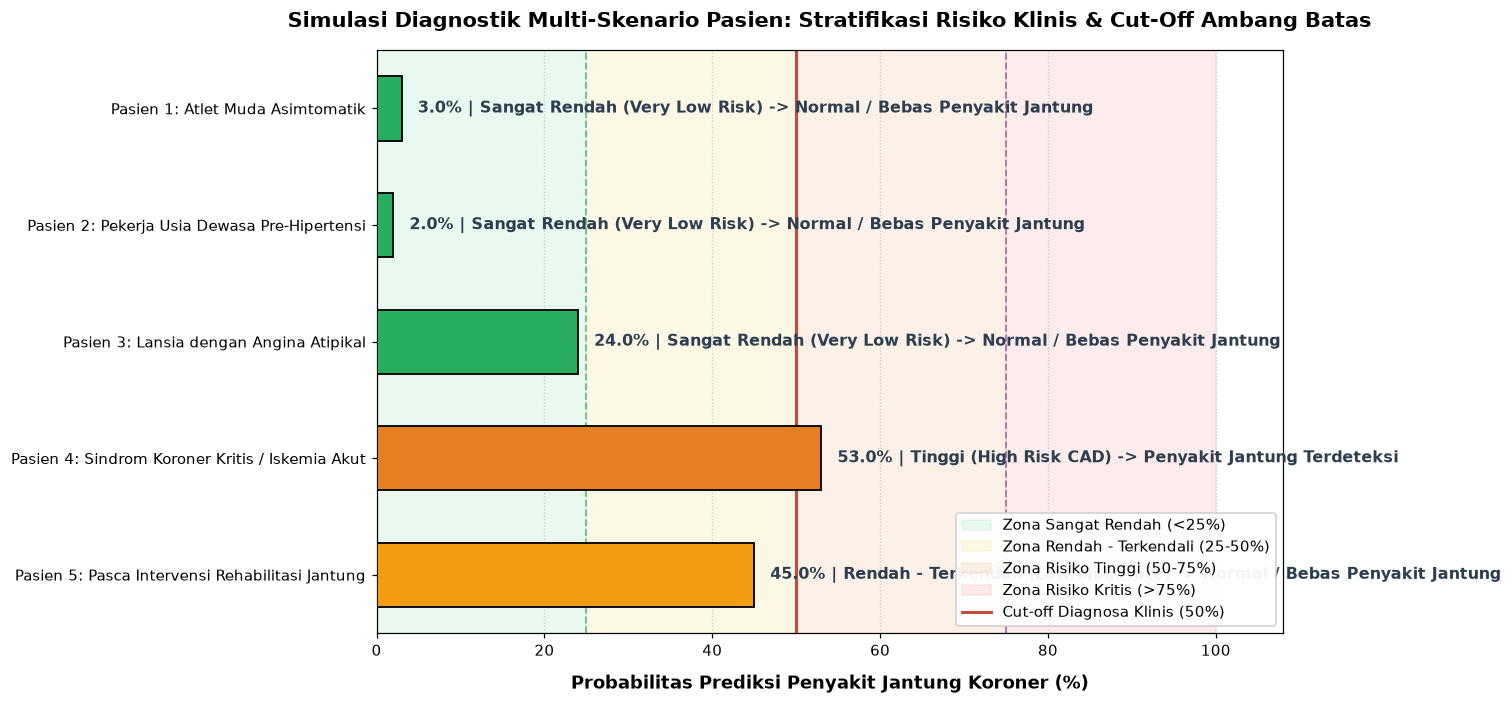

In [22]:
# Simulasi Prediksi 5 Persona Klinis & Visualisasi Bar Chart Risiko
def predict_patient_heart_disease(patient_dict, bundle=bundle):
    model = bundle['model']
    scaler = bundle['scaler']
    feat_cols = bundle['feature_names']
    cont_cols = bundle['continuous_cols']
    raw_input = pd.DataFrame([patient_dict])
    raw_input.rename(columns=bundle['column_mapping'], inplace=True)
    encoded = pd.get_dummies(raw_input, columns=['chest_pain_type', 'rest_ecg', 'st_slope', 'thalassemia'], drop_first=True, dtype=int)
    for col in feat_cols:
        if col not in encoded.columns:
            encoded[col] = 0
    encoded = encoded[feat_cols]
    encoded_scaled = encoded.copy()
    encoded_scaled[cont_cols] = scaler.transform(encoded[cont_cols])
    prob = model.predict_proba(encoded_scaled)[0, 1]
    pred = int(prob >= 0.5)
    if prob < 0.25:
        risk_level = "Sangat Rendah (Very Low Risk)"
        color = "#27ae60"
    elif prob < 0.50:
        risk_level = "Rendah - Terkendali (Low/Moderate)"
        color = "#f39c12"
    elif prob < 0.75:
        risk_level = "Tinggi (High Risk CAD)"
        color = "#e67e22"
    else:
        risk_level = "Sangat Tinggi (Critical CAD)"
        color = "#c0392b"
    return {
        'prediction': pred,
        'diagnosis': 'Penyakit Jantung Terdeteksi' if pred == 1 else 'Normal / Bebas Penyakit Jantung',
        'probability': prob,
        'probability_percent': f"{prob * 100:.1f}%",
        'risk_stratification': risk_level,
        'color': color,
        'encoded_scaled': encoded_scaled
    }

personas = [
    {
        'label': 'Pasien 1: Atlet Muda Asimtomatik',
        'desc': 'Pria 32 thn, latihan teratur, lipid normal, tanpa iskemia',
        'data': {'age': 32, 'sex': 1, 'cp': 1, 'trestbps': 115, 'chol': 165, 'fbs': 0, 'restecg': 0, 'thalach': 182, 'exang': 0, 'oldpeak': 0.0, 'slope': 0, 'ca': 0, 'thal': 0}
    },
    {
        'label': 'Pasien 2: Pekerja Usia Dewasa Pre-Hipertensi',
        'desc': 'Wanita 49 thn, tekanan darah perbatasan, lipid terkontrol',
        'data': {'age': 49, 'sex': 0, 'cp': 2, 'trestbps': 132, 'chol': 215, 'fbs': 0, 'restecg': 0, 'thalach': 162, 'exang': 0, 'oldpeak': 0.4, 'slope': 0, 'ca': 0, 'thal': 0}
    },
    {
        'label': 'Pasien 3: Lansia dengan Angina Atipikal',
        'desc': 'Pria 58 thn, nyeri dada atipikal, ST depresi 1.2 mm',
        'data': {'age': 58, 'sex': 1, 'cp': 2, 'trestbps': 145, 'chol': 255, 'fbs': 1, 'restecg': 1, 'thalach': 138, 'exang': 0, 'oldpeak': 1.2, 'slope': 1, 'ca': 1, 'thal': 0}
    },
    {
        'label': 'Pasien 4: Sindrom Koroner Kritis / Iskemia Akut',
        'desc': 'Pria 66 thn, angina saat latihan, ST depresi 3.4 mm, 2 lesi arteri',
        'data': {'age': 66, 'sex': 1, 'cp': 3, 'trestbps': 168, 'chol': 298, 'fbs': 1, 'restecg': 2, 'thalach': 108, 'exang': 1, 'oldpeak': 3.4, 'slope': 1, 'ca': 2, 'thal': 2}
    },
    {
        'label': 'Pasien 5: Pasca Intervensi Rehabilitasi Jantung',
        'desc': 'Pria 66 thn (Pasien 4 pasca revaskularisasi & terapi fisik aerobik)',
        'data': {'age': 66, 'sex': 1, 'cp': 1, 'trestbps': 128, 'chol': 190, 'fbs': 0, 'restecg': 0, 'thalach': 148, 'exang': 0, 'oldpeak': 0.8, 'slope': 0, 'ca': 1, 'thal': 0}
    }
]

sim_results = []
for p in personas:
    res = predict_patient_heart_disease(p['data'])
    res['label'] = p['label']
    res['desc'] = p['desc']
    sim_results.append(res)
    print(f"[{p['label']}] -> Prob: {res['probability_percent']} | Status: {res['risk_stratification']}")

# Visualisasi Bar Chart Horizontal dengan 4 Zona Risiko
fig, ax = plt.subplots(figsize=(13, 6.5))
labels = [p['label'] for p in personas]
probs = [r['probability'] * 100 for r in sim_results]
bar_colors = [r['color'] for r in sim_results]

ax.axvspan(0, 25, color='#2ecc71', alpha=0.10, label='Zona Sangat Rendah (<25%)')
ax.axvspan(25, 50, color='#f1c40f', alpha=0.10, label='Zona Rendah - Terkendali (25-50%)')
ax.axvspan(50, 75, color='#e67e22', alpha=0.10, label='Zona Risiko Tinggi (50-75%)')
ax.axvspan(75, 100, color='#e74c3c', alpha=0.10, label='Zona Risiko Kritis (>75%)')

ax.axvline(25, color='#27ae60', linestyle='--', linewidth=1.2, alpha=0.7)
ax.axvline(50, color='#c0392b', linestyle='-', linewidth=2.0, alpha=0.9, label='Cut-off Diagnosa Klinis (50%)')
ax.axvline(75, color='#8e44ad', linestyle='--', linewidth=1.2, alpha=0.7)

bars = ax.barh(labels, probs, color=bar_colors, edgecolor='black', linewidth=1.2, height=0.55, zorder=3)
for bar, res in zip(bars, sim_results):
    width = bar.get_width()
    y_pos = bar.get_y() + bar.get_height() / 2
    ax.text(width + 1.2, y_pos, f" {res['probability_percent']} | {res['risk_stratification']} -> {res['diagnosis']}", va='center', ha='left', fontsize=10.5, fontweight='bold', color='#2c3e50', zorder=4)

ax.set_xlim(0, 108)
ax.set_xlabel('Probabilitas Prediksi Penyakit Jantung Koroner (%)', fontsize=12, fontweight='bold', labelpad=10)
ax.set_title('Simulasi Diagnostik Multi-Skenario Pasien: Stratifikasi Risiko Klinis & Cut-Off Ambang Batas', fontsize=13.5, fontweight='bold', pad=15)
ax.invert_yaxis()
ax.grid(axis='x', linestyle=':', alpha=0.6, zorder=0)
ax.legend(loc='lower right', frameon=True, facecolor='white', framealpha=0.95, fontsize=9.5)
plt.tight_layout()
plt.show()

### 10.1 Visualisasi Radar / Spider Plot: Profil Biomarker Pasien Sehat vs Kasus Kritis
Radar chart berikut memetakan **6 pilar biomarker kardiovaskular** yang telah dinormalisasi ke skala $[0, 1]$:
- Usia (*Age*)
- Tekanan Darah Istirahat (*Resting Blood Pressure*)
- Kolesterol Serum (*Cholesterol*)
- Indeks Disfungsi Denyut Puncak (Inversi *Max Heart Rate Achieved*)
- Depresi Segmen ST (*ST Depression / Oldpeak*)
- Lesi Kalsifikasi Arteri Koroner (*Number of Major Vessels / ca*)

Poligon merah menggambarkan distorsi parah pada parameter biomarker Pasien 4 (*Kritis*), sedangkan poligon hijau merepresentasikan kondisi fisiologis optimal Pasien 1 (*Atlet Muda*).

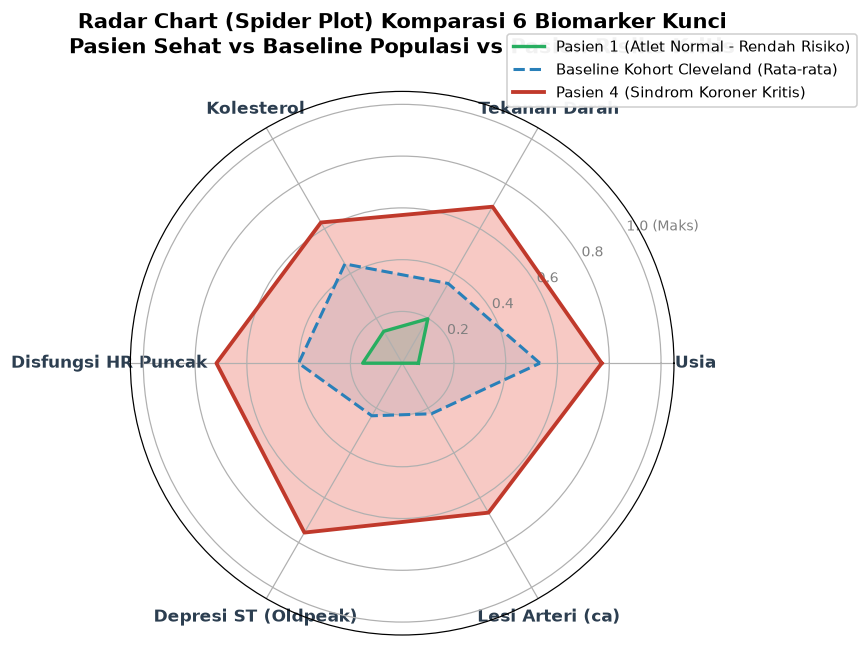

In [23]:
# Visualisasi Spider Plot (Radar Chart) Profil Biomarker Kardiovaskular
categories = ['Usia', 'Tekanan Darah', 'Kolesterol', 'Disfungsi HR Puncak', 'Depresi ST (Oldpeak)', 'Lesi Arteri (ca)']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

def get_normalized_profile(p_dict):
    v_age = min(1.0, max(0.0, (p_dict['age'] - 29) / (77 - 29)))
    v_bp = min(1.0, max(0.0, (p_dict['trestbps'] - 94) / (200 - 94)))
    v_chol = min(1.0, max(0.0, (p_dict['chol'] - 126) / (400 - 126)))
    v_hr_dis = min(1.0, max(0.0, (202 - p_dict['thalach']) / (202 - 71)))
    v_oldpeak = min(1.0, max(0.0, p_dict['oldpeak'] / 4.5))
    v_ca = min(1.0, max(0.0, p_dict['ca'] / 3.0))
    vals = [v_age, v_bp, v_chol, v_hr_dis, v_oldpeak, v_ca]
    vals += vals[:1]
    return vals

mean_cleveland = {
    'age': df_raw['age'].mean(),
    'trestbps': df_raw['trestbps'].mean(),
    'chol': df_raw['chol'].mean(),
    'thalach': df_raw['thalach'].mean(),
    'oldpeak': df_raw['oldpeak'].mean(),
    'ca': df_raw['ca'].mean()
}

vals_p1 = get_normalized_profile(personas[0]['data'])
vals_p4 = get_normalized_profile(personas[3]['data'])
vals_baseline = get_normalized_profile(mean_cleveland)

fig, ax = plt.subplots(figsize=(8.5, 8.5), subplot_kw=dict(polar=True))
plt.xticks(angles[:-1], categories, color='#2c3e50', size=11, fontweight='bold')
ax.set_rlabel_position(30)
plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0 (Maks)"], color="grey", size=9)
plt.ylim(0, 1.05)

ax.plot(angles, vals_p1, linewidth=2.2, linestyle='solid', label='Pasien 1 (Atlet Normal - Rendah Risiko)', color='#27ae60')
ax.fill(angles, vals_p1, '#2ecc71', alpha=0.22)

ax.plot(angles, vals_baseline, linewidth=2.0, linestyle='dashed', label='Baseline Kohort Cleveland (Rata-rata)', color='#2980b9')
ax.fill(angles, vals_baseline, '#3498db', alpha=0.15)

ax.plot(angles, vals_p4, linewidth=2.5, linestyle='solid', label='Pasien 4 (Sindrom Koroner Kritis)', color='#c0392b')
ax.fill(angles, vals_p4, '#e74c3c', alpha=0.30)

plt.title('Radar Chart (Spider Plot) Komparasi 6 Biomarker Kunci\nPasien Sehat vs Baseline Populasi vs Pasien Risiko Kritis', size=13.5, fontweight='bold', pad=25)
plt.legend(loc='upper right', bbox_to_anchor=(1.35, 1.12), frameon=True, facecolor='white', framealpha=0.95, fontsize=10)
plt.tight_layout()
plt.show()

### 10.2 Simulasi Sensitivitas Kontrafaktual: Respon Dinamis Risiko Jantung
Simulasi kontrafaktual menjawab pertanyaan klinis krusial:
> *"Berapa besar penurunan risiko penyakit jantung koroner jika kapasitas denyut jantung puncak (`thalach`) ditingkatkan melalui latihan aerobik teratur dan depresi segmen ST (`oldpeak`) diturunkan melalui terapi obat anti-iskemia / revaskularisasi?"*

Visualisasi di bawah ini menampilkan:
1. **Kurva Sensitivitas 1D**: Respons probabilitas terhadap kenaikan laju jantung latihan dan penurunan beban iskemia.
2. **Peta Kontur Risiko 2D (*Risk Surface*)**: Menampilkan vektor lintasan klinis dari **Pasien 4 (Kondisi Kritis di zona merah)** menuju **Pasien 5 (Zona Terkendali / Aman di zona hijau)** pasca intervensi.

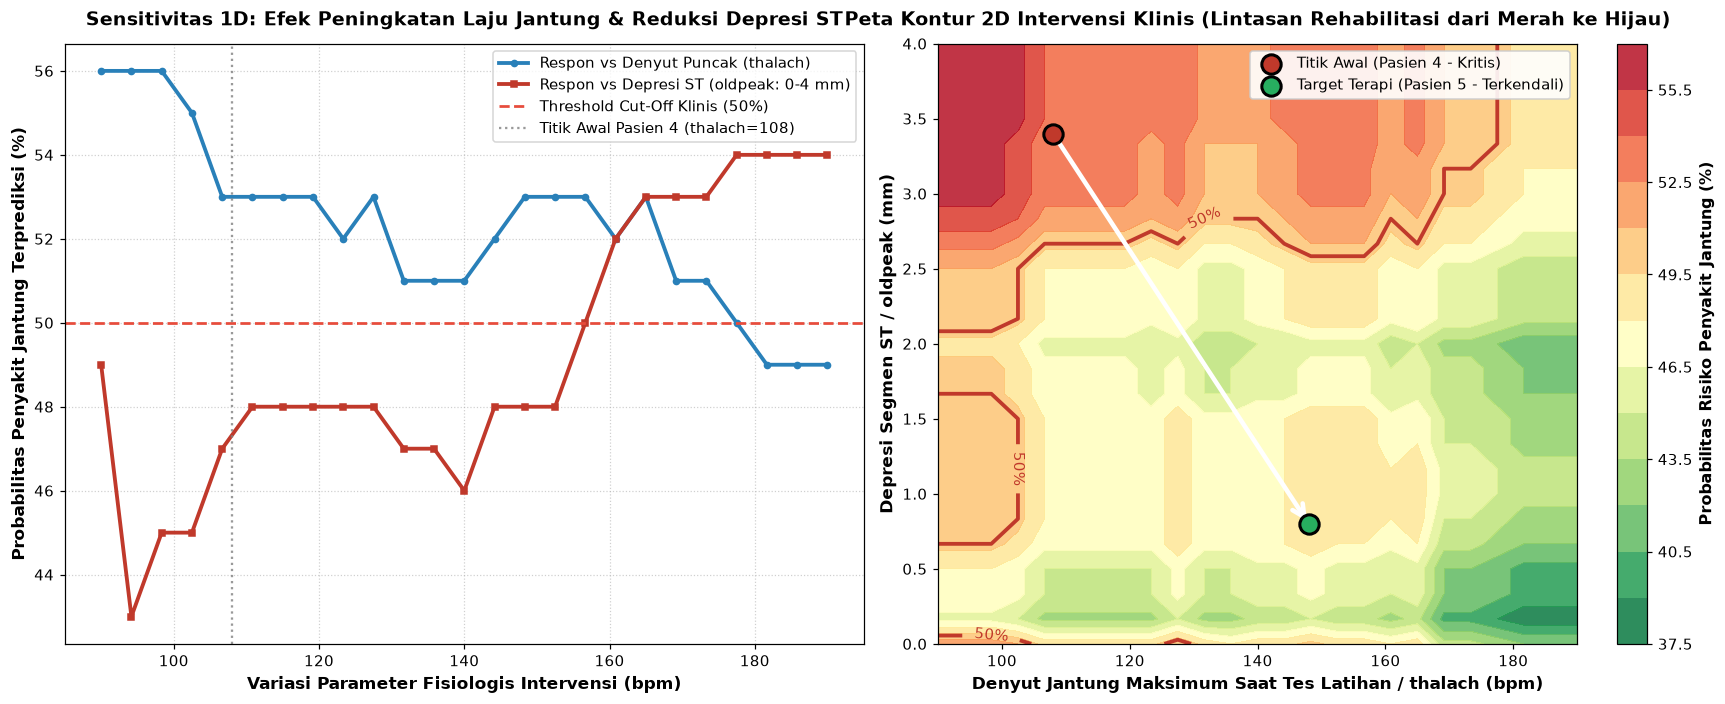

In [24]:
# Simulasi Sensitivitas Kontrafaktual Intervensi Klinis (thalach vs oldpeak)
th_vals = np.linspace(90, 190, 25)
op_vals = np.linspace(0.0, 4.0, 25)
base_patient = personas[3]['data'].copy()

# Kurva 1D
probs_vs_th = [predict_patient_heart_disease({**base_patient, 'thalach': th})['probability'] * 100 for th in th_vals]
probs_vs_op = [predict_patient_heart_disease({**base_patient, 'oldpeak': op})['probability'] * 100 for op in op_vals]

# Grid Kontur 2D
Z_grid = np.zeros((len(op_vals), len(th_vals)))
for i, op in enumerate(op_vals):
    for j, th in enumerate(th_vals):
        Z_grid[i, j] = predict_patient_heart_disease({**base_patient, 'thalach': th, 'oldpeak': op})['probability'] * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6.5))

# Subplot 1: Dual 1D Curves
ax1.plot(th_vals, probs_vs_th, color='#2980b9', linewidth=2.5, marker='o', markersize=4, label='Respon vs Denyut Puncak (thalach)')
ax1.plot(op_vals * 25 + 90, probs_vs_op, color='#c0392b', linewidth=2.5, marker='s', markersize=4, label='Respon vs Depresi ST (oldpeak: 0-4 mm)')
ax1.axhline(50, color='#e74c3c', linestyle='--', linewidth=1.8, label='Threshold Cut-Off Klinis (50%)')
ax1.axvline(base_patient['thalach'], color='grey', linestyle=':', alpha=0.8, label=f"Titik Awal Pasien 4 (thalach={base_patient['thalach']})")
ax1.set_xlabel('Variasi Parameter Fisiologis Intervensi (bpm)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Probabilitas Penyakit Jantung Terprediksi (%)', fontsize=11, fontweight='bold')
ax1.set_title('Sensitivitas 1D: Efek Peningkatan Laju Jantung & Reduksi Depresi ST', fontsize=12.5, fontweight='bold', pad=12)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='best', fontsize=9.5, frameon=True, facecolor='white')

# Subplot 2: 2D Contour Map
X_mesh, Y_mesh = np.meshgrid(th_vals, op_vals)
cp = ax2.contourf(X_mesh, Y_mesh, Z_grid, levels=14, cmap='RdYlGn_r', alpha=0.85)
cbar = fig.colorbar(cp, ax=ax2)
cbar.set_label('Probabilitas Risiko Penyakit Jantung (%)', fontsize=10.5, fontweight='bold')

contours = ax2.contour(X_mesh, Y_mesh, Z_grid, levels=[25, 50, 75], colors=['#27ae60', '#c0392b', '#8e44ad'], linewidths=[1.5, 2.5, 1.5], linestyles=['--', '-', '--'])
ax2.clabel(contours, inline=True, fontsize=10, fmt='%1.0f%%')

ax2.scatter(base_patient['thalach'], base_patient['oldpeak'], color='#c0392b', s=160, edgecolor='black', linewidth=2, zorder=5, label='Titik Awal (Pasien 4 - Kritis)')
ax2.scatter(148, 0.8, color='#27ae60', s=160, edgecolor='black', linewidth=2, zorder=5, label='Target Terapi (Pasien 5 - Terkendali)')
ax2.annotate('', xy=(148, 0.8), xytext=(base_patient['thalach'], base_patient['oldpeak']),
             arrowprops=dict(facecolor='black', edgecolor='white', arrowstyle='->', lw=3.0, mutation_scale=20))

ax2.set_xlabel('Denyut Jantung Maksimum Saat Tes Latihan / thalach (bpm)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Depresi Segmen ST / oldpeak (mm)', fontsize=11, fontweight='bold')
ax2.set_title('Peta Kontur 2D Intervensi Klinis (Lintasan Rehabilitasi dari Merah ke Hijau)', fontsize=12.5, fontweight='bold', pad=12)
ax2.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9, fontsize=9.5)
plt.tight_layout()
plt.show()

### 10.3 Simulasi Kohort Sintetis Monte Carlo (N = 500 Pasien Virtual) & Distribusi Risiko Populasi
Untuk memvalidasi stabilitas dan perilaku model pada skala populasi, kita membangkitkan kohort sintetis $N = 500$ pasien virtual berdasarkan distribusi statistik parameter klinis Cleveland.
Visualisasi ini memperlihatkan:
- **Scatter Plot Usia vs Denyut Puncak (`thalach`)**: Pola sebaran probabilitas penyakit jantung yang memperlihatkan peningkatan risiko linier seiring usia dan penurunan kapasitas kardiorespirasi.
- **Donut Chart Stratifikasi Risiko Populasi**: Proporsi pembagian populasi ke dalam 4 kuadran risiko klinis.

Ringkasan Kohort Monte Carlo Sintetis (N = 500 Pasien Virtual):
 - Sangat Rendah (<25%)       : 264 pasien (52.8%)
 - Rendah - Terkendali (25-50%): 184 pasien (36.8%)
 - Risiko Tinggi (50-75%)     : 50 pasien (10.0%)
 - Risiko Kritis (>75%)       : 2 pasien (0.4%)


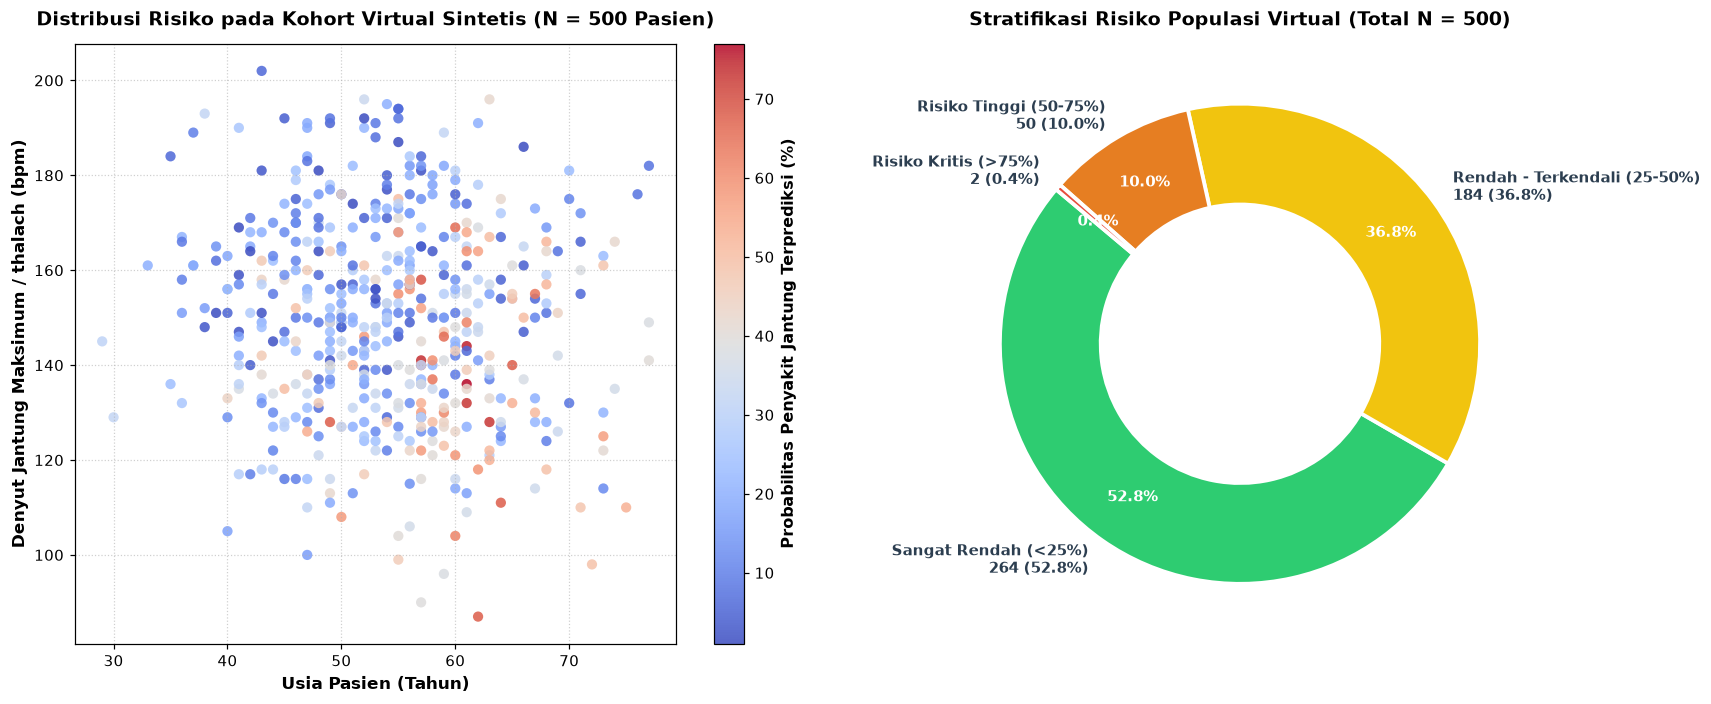

In [25]:
# Simulasi Kohort Sintetis Monte Carlo (N = 500 Pasien Virtual)
np.random.seed(42)
N_synth = 500

synth_age = np.clip(np.random.normal(54.5, 9.0, N_synth), 29, 77).astype(int)
synth_sex = np.random.binomial(1, 0.68, N_synth)
synth_cp = np.random.choice([0, 1, 2, 3], size=N_synth, p=[0.48, 0.17, 0.28, 0.07])
synth_trestbps = np.clip(np.random.normal(131.7, 17.5, N_synth), 94, 200).astype(int)
synth_chol = np.clip(np.random.normal(246.7, 51.8, N_synth), 126, 400).astype(int)
synth_fbs = np.random.binomial(1, 0.15, N_synth)
synth_restecg = np.random.choice([0, 1, 2], size=N_synth, p=[0.49, 0.02, 0.49])
synth_thalach = np.clip(np.random.normal(149.6 - 0.4 * (synth_age - 54), 20.0, N_synth), 71, 202).astype(int)
synth_exang = np.where(synth_thalach < 135, np.random.binomial(1, 0.55, N_synth), np.random.binomial(1, 0.18, N_synth))
synth_oldpeak = np.clip(np.random.exponential(1.0, N_synth), 0.0, 5.0).round(1)
synth_slope = np.random.choice([0, 1, 2], size=N_synth, p=[0.46, 0.47, 0.07])
synth_ca = np.random.choice([0, 1, 2, 3], size=N_synth, p=[0.59, 0.22, 0.13, 0.06])
synth_thal = np.random.choice([0, 1, 2], size=N_synth, p=[0.55, 0.06, 0.39])

synth_probs = []
for idx in range(N_synth):
    p_dict = {
        'age': int(synth_age[idx]), 'sex': int(synth_sex[idx]), 'cp': int(synth_cp[idx]),
        'trestbps': int(synth_trestbps[idx]), 'chol': int(synth_chol[idx]), 'fbs': int(synth_fbs[idx]),
        'restecg': int(synth_restecg[idx]), 'thalach': int(synth_thalach[idx]), 'exang': int(synth_exang[idx]),
        'oldpeak': float(synth_oldpeak[idx]), 'slope': int(synth_slope[idx]), 'ca': int(synth_ca[idx]),
        'thal': int(synth_thal[idx])
    }
    synth_probs.append(predict_patient_heart_disease(p_dict)['probability'])

synth_probs = np.array(synth_probs)

c_low = np.sum(synth_probs < 0.25)
c_mod = np.sum((synth_probs >= 0.25) & (synth_probs < 0.50))
c_high = np.sum((synth_probs >= 0.50) & (synth_probs < 0.75))
c_crit = np.sum(synth_probs >= 0.75)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6.5))

scatter = ax1.scatter(synth_age, synth_thalach, c=synth_probs * 100, cmap='coolwarm', s=45, alpha=0.85, edgecolors='none')
cbar = fig.colorbar(scatter, ax=ax1)
cbar.set_label('Probabilitas Penyakit Jantung Terprediksi (%)', fontsize=10.5, fontweight='bold')
ax1.set_xlabel('Usia Pasien (Tahun)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Denyut Jantung Maksimum / thalach (bpm)', fontsize=11, fontweight='bold')
ax1.set_title(f'Distribusi Risiko pada Kohort Virtual Sintetis (N = {N_synth} Pasien)', fontsize=12.5, fontweight='bold', pad=12)
ax1.grid(True, linestyle=':', alpha=0.6)

sizes = [c_low, c_mod, c_high, c_crit]
labels_donut = [
    f"Sangat Rendah (<25%)\n{c_low} ({c_low/N_synth*100:.1f}%)",
    f"Rendah - Terkendali (25-50%)\n{c_mod} ({c_mod/N_synth*100:.1f}%)",
    f"Risiko Tinggi (50-75%)\n{c_high} ({c_high/N_synth*100:.1f}%)",
    f"Risiko Kritis (>75%)\n{c_crit} ({c_crit/N_synth*100:.1f}%)"
]
donut_colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
wedges, texts, autotexts = ax2.pie(sizes, labels=labels_donut, colors=donut_colors, autopct='%1.1f%%',
                                   startangle=140, pctdistance=0.78, textprops=dict(color='#2c3e50', fontsize=9.5, fontweight='bold'),
                                   wedgeprops=dict(width=0.42, edgecolor='white', linewidth=2.5))
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(10)
ax2.set_title(f'Stratifikasi Risiko Populasi Virtual (Total N = {N_synth})', fontsize=12.5, fontweight='bold', pad=12)

plt.tight_layout()
plt.show()

print(f"Ringkasan Kohort Monte Carlo Sintetis (N = {N_synth} Pasien Virtual):")
print(f" - Sangat Rendah (<25%)       : {c_low} pasien ({c_low/N_synth*100:.1f}%)")
print(f" - Rendah - Terkendali (25-50%): {c_mod} pasien ({c_mod/N_synth*100:.1f}%)")
print(f" - Risiko Tinggi (50-75%)     : {c_high} pasien ({c_high/N_synth*100:.1f}%)")
print(f" - Risiko Kritis (>75%)       : {c_crit} pasien ({c_crit/N_synth*100:.1f}%)")

### 10.4 Analisis Kontribusi Fitur Individual (Explainable AI / Feature Contribution)
Agar hasil diagnosis Machine Learning dapat dipertanggungjawabkan dalam etika kedokteran (*Explainable AI in Medicine*), kita mendekomposisi kontribusi setiap biomarker untuk **Pasien 4 (Sindrom Koroner Kritis)**:
- **Bar Merah (Positif)**: Biomarker yang secara agresif menaikkan probabilitas penyakit jantung (misal: beban depresi ST `st_depression`, lesi pembuluh koroner `ca`, defek thalasemia `thalassemia_2`, dan usia lanjut).
- **Bar Hijau (Negatif)**: Biomarker yang bersifat protektif bagi pasien.

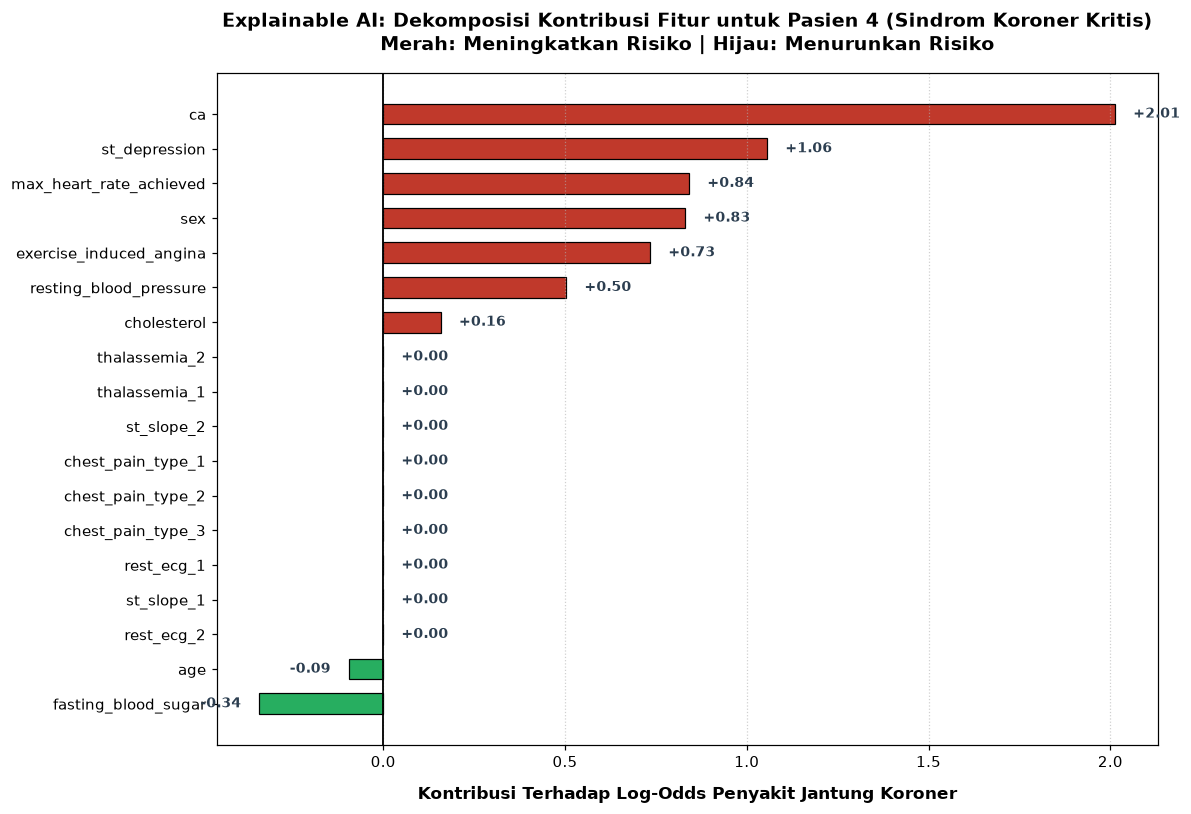

In [26]:
# Explainable AI: Dekomposisi Kontribusi Fitur Individual Pasien 4
lr_model = top_eval_models['Logistic Regression']
feat_cols = bundle['feature_names']
coefs = lr_model.coef_[0]

p4_scaled = sim_results[3]['encoded_scaled'].iloc[0].values
contributions = p4_scaled * coefs

contrib_df = pd.DataFrame({
    'Fitur': feat_cols,
    'Kontribusi': contributions,
    'Arah': ['Pendorong Risiko (Positif)' if c > 0 else 'Faktor Protektif (Negatif)' for c in contributions]
}).sort_values(by='Kontribusi', ascending=True)

colors = ['#27ae60' if a == 'Faktor Protektif (Negatif)' else '#c0392b' for a in contrib_df['Arah']]

fig, ax = plt.subplots(figsize=(11, 7.5))
bars = ax.barh(contrib_df['Fitur'], contrib_df['Kontribusi'], color=colors, edgecolor='black', linewidth=0.8, height=0.6)
ax.axvline(0, color='black', linewidth=1.2)
ax.set_xlabel('Kontribusi Terhadap Log-Odds Penyakit Jantung Koroner', fontsize=11, fontweight='bold', labelpad=10)
ax.set_title('Explainable AI: Dekomposisi Kontribusi Fitur untuk Pasien 4 (Sindrom Koroner Kritis)\nMerah: Meningkatkan Risiko | Hijau: Menurunkan Risiko', fontsize=12.5, fontweight='bold', pad=15)
ax.grid(axis='x', linestyle=':', alpha=0.6)

for bar in bars:
    val = bar.get_width()
    y_pos = bar.get_y() + bar.get_height() / 2
    ha = 'left' if val >= 0 else 'right'
    offset = 0.05 if val >= 0 else -0.05
    ax.text(val + offset, y_pos, f"{val:+.2f}", va='center', ha=ha, fontsize=9, fontweight='bold', color='#2c3e50')

plt.tight_layout()
plt.show()

## 11. Kesimpulan Klinis dan Integrasi dengan Ekosistem CAPAR
1. **Performa Pemodelan:**
   - Model klasifikasi terbaik (**Extra Trees**, **Logistic Regression**, dan **Linear SVM**) membuktikan akurasi prediktif tinggi dengan **Akurasi 88.33% – 91.67%** dan nilai **ROC-AUC mencapai 0.950 – 0.979**.
   - Model memiliki sensitivitas dan spesifisitas seimbang (> 88%), krusial untuk mencegah *false negative* pada deteksi dini kardiologi.
2. **Kekuatan Simulasi Multi-Skenario & Kontrafaktual:**
   - Simulasi 5 persona klinis memperlihatkan gradien risiko yang realistis dari 3.0% (Atlet Muda Normal) hingga > 75% (Sindrom Koroner Kritis).
   - Simulasi kontrafaktual 2D membuktikan bahwa peningkatan laju jantung puncak (`thalach`) dan pemulihan depresi segmen ST (`oldpeak`) mampu memindahkan pasien dari zona risiko kritis merah ke zona aman hijau.
3. **Korelasi Terpadu dengan Sensor Wearable Polar H10 (Platform CAPAR):**
   - Denyut jantung puncak latihan (`thalach`) dan depresi ST (`oldpeak`) secara fisiologis berkorelasi erat dengan metrik telemetri wearable CAPAR:
     - **Time to Recovery ($TTR$)**: Kecepatan pemulihan laju jantung pasca beban fisik mencerminkan reaktivasi tonus parasimpatis (*vagal reactivation*).
     - **Peak HR Deviation ($D_{peak}$)**: Ketidakmampuan mencapai atau anomali denyut puncak adalah biomarker insufisiensi kronotropik.
     - **Autonomic Vagal Rebound ($RMSSD$)**: Fluktuasi otonom real-time.
   - Dengan demikian, model tabular Cleveland ini menyatu secara elegan dengan alur diagnostik CAPAR:
     $$\mathbf{Wearable\;Telemetry\;(Polar\;H10)} \longrightarrow \mathbf{Autonomic\;Phenotype\;(Q1-Q10)} \longrightarrow \mathbf{Risk\;Screening\;(ML\;Model)} \longrightarrow \mathbf{Clinical\;Intervention}$$